In [147]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras import layers
import openpyxl as xl
from openpyxl.styles import Font
import os

In [ ]:
#Coletando dados

df = pd.read_excel('/Users/PC/Documents/Proj_MPA/Recontrucao/Para/3-Clupeiformes/R.xlsx')



#Dados iniciais
df_especies = df[['Ano',"Pesc_amarela_ind", "Pesc_cambucu_ind", "Pescadinha_ind"]].dropna().reset_index(drop=True)
anos_para_prever = np.array([*range(1963,1965),*range(1966,1969), *range(1970,1974),*range(1976,1980),1996])

lista_de_prop=[] #lista onde ficam os arrays com as proporções para cada especie
especies = df_especies.drop('Ano',axis=1).columns.to_numpy() #lista das especies

#Coluna da soma
for i in range(len(df_especies['Ano'])):
  df_especies.loc[i,'Soma'] = df_especies.iloc[i,1:].sum() 


for k in range(len(especies)):

     dados = df_especies[['Ano',especies[k],'Soma']]
     
     #Fazendo as proporções de cada especie em relação à soma
     for i in range(len(dados['Ano'])):
       if dados.loc[i,'Soma']!=0:
           dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'Soma']
     
     
     anos_com_dados = dados["Ano"].values
     todos_anos = np.concatenate((anos_para_prever, anos_com_dados))
     todos_anos.sort()
     
     prop= dados['Prop_'+especies[k]].values
     lista_de_prop.append(prop)
     print(dados.head())



    Ano  Pesc_amarela_ind   Soma  Prop_Pesc_amarela_ind
0  1980               4.0   49.0               0.081633
1  1981               1.0   86.0               0.011628
2  1987               9.0  530.0               0.016981
3  1996             144.0  436.5               0.329897
4  1997             614.0  746.5               0.822505
    Ano  Pesc_cambucu_ind   Soma  Prop_Pesc_cambucu_ind
0  1980              11.0   49.0               0.224490
1  1981              27.0   86.0               0.313953
2  1987              28.0  530.0               0.052830
3  1996               8.5  436.5               0.019473
4  1997              39.0  746.5               0.052244
    Ano  Pescadinha_ind   Soma  Prop_Pescadinha_ind
0  1980            34.0   49.0             0.693878
1  1981            58.0   86.0             0.674419
2  1987           493.0  530.0             0.930189
3  1996           284.0  436.5             0.650630
4  1997            93.5  746.5             0.125251


C:\Users\PC\AppData\Local\Temp\ipykernel_16024\1000226536.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'Soma']
C:\Users\PC\AppData\Local\Temp\ipykernel_16024\1000226536.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'Soma']
C:\Users\PC\AppData\Local\Temp\ipykernel_16024\1000226536.py:26: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [149]:
#Normalização dos dados
ano_mean = np.mean(anos_com_dados)
ano_std = np.std(anos_com_dados)
anos_para_prever_norm = (anos_para_prever - ano_mean)/ano_std
anos_com_dados_norm = (anos_com_dados - ano_mean)/ano_std

lista_prop_norm=[]  #lista com as proporçãoes normalizads para cada especie

lista_prop_mean=[]  #listas para aplicar a inversa da normalização
lista_prop_std=[]

for k in range(len(lista_de_prop)):
    prop_mean = np.mean(lista_de_prop[k])
    prop_std = np.std(lista_de_prop[k])
    prop_norm = (lista_de_prop[k] - prop_mean)/prop_std

    lista_prop_norm.append(prop_norm)
    lista_prop_mean.append(prop_mean)
    lista_prop_std.append(prop_std)

print(lista_prop_norm)


[array([-1.18206543, -1.40453907, -1.38752663, -0.39308675,  1.17241167,
        0.49861283,  0.06878933,  0.45425213,  1.50771046,  0.66544145]), array([ 0.54104932,  1.14481631, -0.61743634, -0.8425547 , -0.62139369,
       -0.79981245,  2.204183  ,  0.50258437, -0.87076632, -0.6406695 ]), array([ 0.98415574,  0.91852296,  1.7812059 ,  0.83828678, -0.93375541,
       -0.12946239, -1.17461492, -0.73329303, -1.16498657, -0.38605907])]


In [ ]:
#Criação das pastas onde serão armazenados os pesos
for esp in especies:
    folder_path = f'/Users/PC/Documents/Proj_MPA/Recontrucao/Para/3-Clupeiformes/Desagregação/Pescada_ind/pesos prop {esp}'
    os.makedirs(folder_path, exist_ok=True) 


#Função para fazer o Fit do modelo e salvar seus pesos para cada especie
def Fit_das_proporcoes(anos_com_dados_norm,
                       lista_prop_norm,
                       lista_de_epocas,
                       lista_de_otimizadores,
                       lista_de_overwrite,
                       especies):
    
    model = keras.Sequential([layers.Dense(96,activation='leaky_relu',input_shape=(1,)),
                                 layers.Dense(32,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(96,activation='leaky_relu'),
                                 layers.Dense(112,activation='leaky_relu'),
                                 layers.Dense(1,activation='linear')])
    
    lista_de_loss=[]
    for k in range(len(especies)):
        opt =  lista_de_otimizadores[k]            #keras.optimizers.Nadam(learning_rate=0.001)
        model.compile(optimizer=opt, loss='mse')
        
        
        history = model.fit(anos_com_dados_norm,lista_prop_norm[k], epochs=lista_de_epocas[k], verbose=0)
        lista_de_loss.append(history.history['loss'])

        
        model.save_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/Para/3-Clupeiformes/Desagregação/Pescada_ind/pesos prop {especies[k]}/.weights.h5', overwrite=lista_de_overwrite[k])
    return model,lista_de_loss

In [151]:
#Fit do modelo
Nadam= keras.optimizers.Nadam(learning_rate=0.001)
Adam= keras.optimizers.Adam(learning_rate=0.001)

lista_de_epocas=[500,500,500,500,500,500,500,500,500]
lista_de_otimizadores=[Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam]
lista_de_overwrite = [True,True,True,True,True,True,True,True,True]
model,lista_de_loss = Fit_das_proporcoes(anos_com_dados_norm,
                                         lista_prop_norm,
                                         lista_de_epocas,
                                         lista_de_otimizadores,
                                         lista_de_overwrite,
                                         especies)



c:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Previsões para cada especie
lista_de_previsoes=[]
lista_fits=[]

p = np.linspace(-2,2,50)
for k in range(len(especies)):
    
    model.load_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/Para/3-Clupeiformes/Desagregação/Pescada_ind/pesos prop {especies[k]}/.weights.h5')

    prev_ausentes = model.predict(anos_para_prever_norm)*lista_prop_std[k] + lista_prop_mean[k]
    fit = model.predict(p)*lista_prop_std[k] + lista_prop_mean[k]
    #Colocando valores negativos para 0 e proporções no maximo 1
    for i in range(len(prev_ausentes)):
        if prev_ausentes[i]<0:
            prev_ausentes[i]=0
        if prev_ausentes[i]>1:
            prev_ausentes[i]=1

    lista_de_previsoes.append(prev_ausentes)
    lista_fits.append(fit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


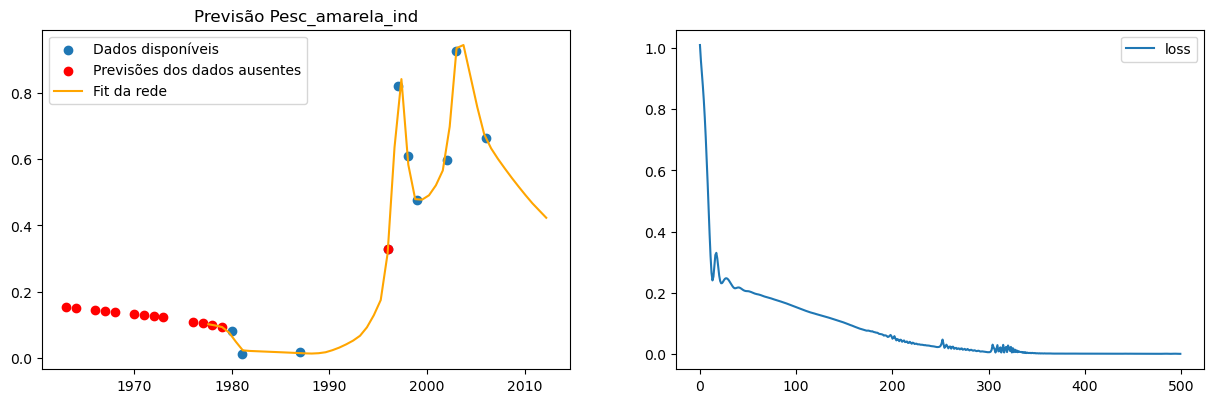

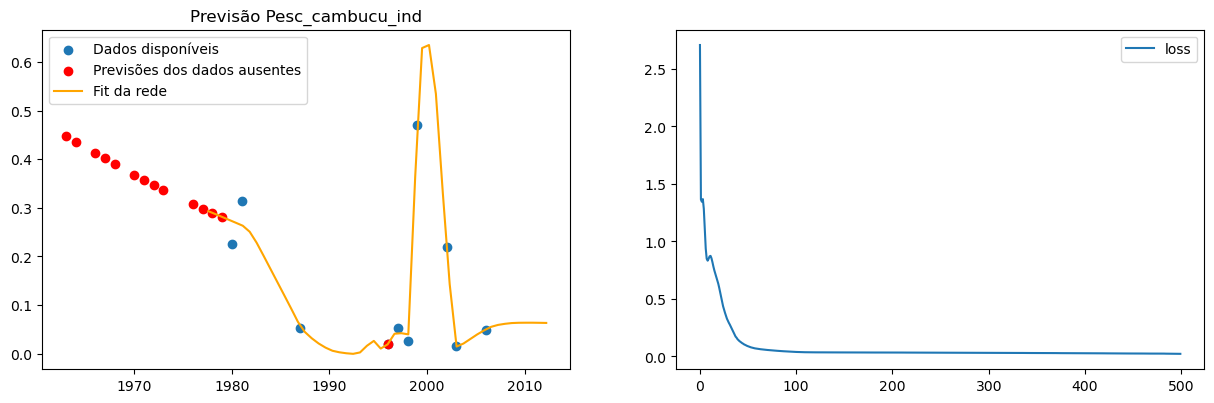

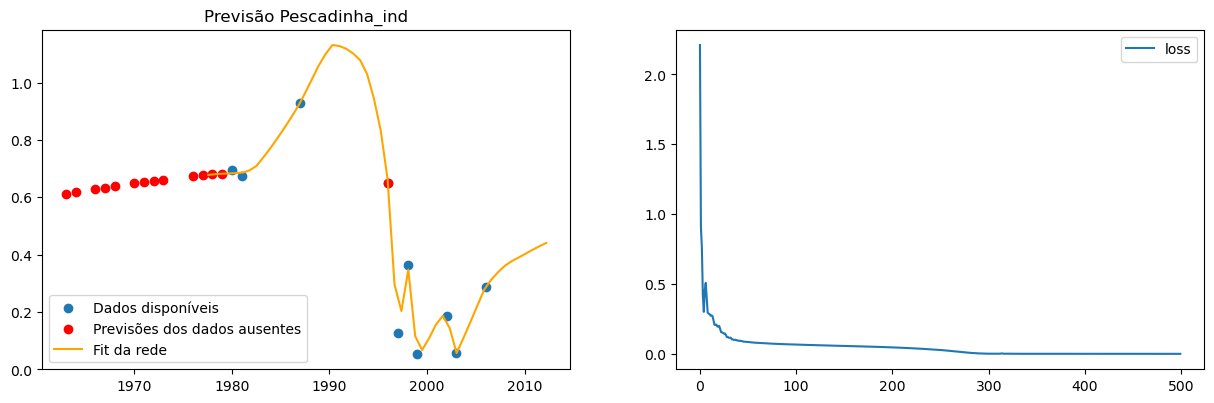

In [153]:
#Plot das previsoes e loss para cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,5*len(especies)))
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_com_dados,lista_de_prop[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_para_prever,lista_de_previsoes[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*ano_std + ano_mean,lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [ ]:
#Lista de anos sem buracos normalizada e sua predição      (para poder me referir por indices)
anos = np.arange(1950,np.max(anos_para_prever)+1)
anos_norm = (anos-ano_mean)/ano_std

#Previsoes sem buracos para cada especie
lista_prev_continua=[]
for k in range(len(especies)):
    model.load_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/Para/3-Clupeiformes/Desagregação/Pescada_ind/pesos prop {especies[k]}/.weights.h5')
    prev_continua = model.predict(anos_norm)*lista_prop_std[k] + lista_prop_mean[k]
    
    for i in range(len(prev_continua)):
        if prev_continua[i]<0:
            prev_continua[i]=0
        if prev_continua[i]>=1:
            prev_continua[i]=1
    
    lista_prev_continua.append(prev_continua.flatten())
  


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [155]:
#Soma das proporções
prop_soma = np.zeros(len(anos))
for k in range(len(especies)):
    prop_soma+=lista_prev_continua[k]

#Dividindo proporções pela soma para que de sempre 1
for k in range(len(especies)):
  lista_prev_continua[k] /= prop_soma 
print(lista_prev_continua[1])

[0.44849518 0.44326374 0.43794757 0.43254137 0.4270407  0.4214266
 0.41574344 0.40997264 0.40378433 0.3971991  0.39041996 0.38358676
 0.3766925  0.36973965 0.36275312 0.35584137 0.3488277  0.34169468
 0.3345617  0.32750344 0.32040522 0.31348592 0.30683348 0.30037743
 0.2941677  0.28829038 0.28220487 0.27652895 0.2711138  0.26636884
 0.26705158 0.2712349  0.25513175 0.22010192 0.17910685 0.1379274
 0.09712335 0.05606661 0.03329006 0.01857775 0.00774118 0.00249424
 0.00057309 0.00122517 0.0153083  0.01552665 0.0198479 ]


In [156]:
#Dicionario dos indices das espécie para prever e da que será desagregada
especies_com_desagregada = np.append(especies,"Pescada_ind") 
todas_colunas=df.columns.to_numpy()
dic_especies={}
for k in range(len(especies_com_desagregada)):
    for i in range(len(todas_colunas)):
        if especies_com_desagregada[k]==todas_colunas[i]:
            dic_especies[especies_com_desagregada[k]]=i+1 #Índices do openpyxl
            break
print(dic_especies)

{'Pesc_amarela_ind': 11, 'Pesc_cambucu_ind': 13, 'Pescadinha_ind': 15, 'Pescada_ind': 6}


In [ ]:
#Adicionando novos dados na planilha e colorindo
wb = xl.load_workbook('/Users/PC/Documents/Proj_MPA/Recontrucao/Para/3-Clupeiformes/R.xlsx')
ws=wb.active

for k in range(len(especies)):
    for i in range(len(anos)):
        celula=ws.cell(anos[i]-1950+2 , dic_especies[especies[k]])
        
        #Dados desagregados para células com valores mantém a cor
        if i+1950 in anos_para_prever and pd.isnull(celula.value)==False:   
          celula.value += ws.cell(anos[i]-1950+2, dic_especies["Pescada_ind"]).value*lista_prev_continua[k][i]
          celula.font = Font(color=celula.font.color,name='Calibri')


        #Dados desagregados para celulas vazias são colocados em vermelho
        if i+1950 in anos_para_prever and pd.isnull(celula.value)==True:
          celula.value = ws.cell(anos[i]-1950+2, dic_especies["Pescada_ind"]).value*lista_prev_continua[k][i]
          celula.font = Font(color='FFFF0000',name='Calibri')
          

      

wb.save('Desag_Pescada_ind.xlsx')